In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)
import sys
# sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import mdata_utils 
import TCR_embedings

2026-05-13 17:12:39.236892: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-13 17:12:39.237181: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-13 17:12:39.265867: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-13 17:12:41.139527: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different compu

In [2]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse

In [3]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/Tumor/GSE139555_2019/data/Processed/"
filename = "CD8_DE2500_singleVDJ_emb.h5mu"
DATA_PATH = path + filename

mdata_ori = mu.read(DATA_PATH)
mdata = mdata_ori.copy()

In [4]:
mdata

MuData object with n_obs × n_vars = 14957 × 2500
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'tcr_embs_feature_names'
  obsm:	'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	14957 x 2500
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'hvg', 'log1p', 'neighbors', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    airr:	14957 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [5]:
# subseting on single pair
mdata = mdata[mdata['airr'].obs['chain_pairing'].isin(['single pair'])]
# mdata = mdata[mdata['gex'].obs['COMBAT_ID'].astype(int) > 20]
# mdata = mdata_utils.sync_mdata_obs(mdata)


In [7]:
## select one cell from each clonotype
airr_obs = mdata['airr'].obs.copy()
clone_id_col = airr_obs['clone_id']
if hasattr(clone_id_col, 'cat'):
    clone_id_col = clone_id_col.astype(str)
airr_obs['_clone_id_str'] = clone_id_col

expanded = airr_obs[airr_obs['clone_id_size'] > 1].dropna(subset=['_clone_id_str'])
sampled_expanded_idx = (
    expanded
    .groupby('_clone_id_str', observed=True)
    .sample(n=1, random_state=42)
    .index
)

single_idx = airr_obs[airr_obs['clone_id_size'] == 1].index
keep_idx = sampled_expanded_idx.append(single_idx)

mdata = mdata[keep_idx].copy()
print(f"Expanded clones: {len(expanded)} cells -> {len(sampled_expanded_idx)} (1 per clone)")
print(f"Single clones: {len(single_idx)}")
print(f"Total after dedup: {mdata.n_obs} cells")


Expanded clones: 11391 cells -> 1361 (1 per clone)
Single clones: 3566
Total after dedup: 4927 cells


In [8]:
gex = mdata['gex']
tcr_embs = mdata.obsm['tcr_embs']

#### no subsetteing  ####
view_gene = gex.X.toarray()
# view_gene = np.asarray(view_gene, dtype=float)
view_tcr = np.asarray(tcr_embs, dtype=float)

scaler = StandardScaler()
view_gene = scaler.fit_transform(view_gene)
view_tcr = scaler.fit_transform(view_tcr)

print(f"view_gene: {view_gene.shape} ")
print(f"view_tcr:  {view_tcr.shape}  ")

view_gene: (4927, 2500) 
view_tcr:  (4927, 244)  


## CCA

In [9]:
### Train / test split + dataloaders ###
from sklearn.model_selection import train_test_split
mdata.obs['set'] = ''

train_frac = 0.8
dim_cca = min(view_gene.shape[1], view_tcr.shape[1], 5)

train_mask = np.random.rand(mdata.n_obs) < train_frac
test_mask = ~train_mask
mdata.obs.loc[train_mask, 'set'] = 'train'
mdata.obs.loc[test_mask, 'set'] = 'test'

view_gene_train = view_gene[train_mask]
view_gene_test = view_gene[test_mask]
view_tcr_train = view_tcr[train_mask]
view_tcr_test = view_tcr[test_mask]

print(f"Train: {view_gene_train.shape[0]}  Test: {view_gene_test.shape[0]}")
print(f"Latent dims (dim_cca): {dim_cca}")

Train: 3944  Test: 983
Latent dims (dim_cca): 5


In [10]:
### Deep CCA: fit ###
sys.path.append(r"/ihome/ylee/yiz133/Code/Tools/")

# from cca_zoo.deep import DCCA, architectures
# from cca_zoo.deep.data import NumpyDataset, check_dataset, get_dataloaders
# import lightning.pytorch as pl

# LATENT_DIMS = dim_cca
# EPOCHS = 30
# BATCH_SIZE = 64

# train_dataset = NumpyDataset([view_gene_train, view_tcr_train])
# test_dataset = NumpyDataset([view_gene_test, view_tcr_test])

# train_loader = get_dataloaders(train_dataset, batch_size=BATCH_SIZE)
# test_loader = get_dataloaders(test_dataset, batch_size=BATCH_SIZE)

# encoder_1 = architectures.Encoder(
#     latent_dimensions=LATENT_DIMS, feature_size=view_gene_train.shape[1],
# )
# encoder_2 = architectures.Encoder(
#     latent_dimensions=LATENT_DIMS, feature_size=view_tcr_train.shape[1],
# )

# dcca = DCCA(latent_dimensions=LATENT_DIMS, encoders=[encoder_1, encoder_2])
# trainer = pl.Trainer(
#     max_epochs=EPOCHS,
#     enable_checkpointing=True,
#     enable_model_summary=True,
#     enable_progress_bar=True,
# )
# trainer.fit(dcca, train_loader)

# from torch.utils.data import DataLoader
# train_loader_full = DataLoader(NumpyDataset([view_gene_train, view_tcr_train]), batch_size=BATCH_SIZE, drop_last=False, shuffle=False)
# test_loader_full = DataLoader(NumpyDataset([view_gene_test, view_tcr_test]), batch_size=BATCH_SIZE, drop_last=False, shuffle=False)
# view_gene_c_train, view_tcr_c_train = cca.transform(train_loader_full)
# view_gene_c_test, view_tcr_c_test = cca.transform(test_loader_full)

In [11]:
# self CCA
dim_cca = 5
# cca = TCR_embedings.CCA(n_components=dim_cca) 
cca = TCR_embedings.rCCA(n_components=dim_cca, alpha_x=1, alpha_y=1,)

view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)
view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)

In [12]:
# Standardise canonical variates
        
view_gene_c_train = scaler.fit_transform(view_gene_c_train)
view_tcr_c_train = scaler.fit_transform(view_tcr_c_train)
view_gene_c_test = scaler.fit_transform(view_gene_c_test)
view_tcr_c_test = scaler.fit_transform(view_tcr_c_test)

# Combine into full-dataset arrays
view_gene_c = np.zeros((mdata.n_obs, dim_cca))
view_tcr_c = np.zeros((mdata.n_obs, dim_cca))
view_gene_c[train_mask] = view_gene_c_train
view_gene_c[test_mask] = view_gene_c_test
view_tcr_c[train_mask] = view_tcr_c_train
view_tcr_c[test_mask] = view_tcr_c_test

# Store canonical variate scores in mdata
for i in range(dim_cca):
    mdata['gex'].obs[f'DCCA_CV_{i}'] = view_tcr_c[:, i]

# Per-component correlations
print("Per-component correlations (train / test):")
for i in range(dim_cca):
    r_tr = np.corrcoef(view_gene_c_train[:, i], view_tcr_c_train[:, i])[0, 1]
    r_te = np.corrcoef(view_gene_c_test[:, i], view_tcr_c_test[:, i])[0, 1]
    print(f"  CC {i}: train {r_tr:.4f}  test {r_te:.4f}")

print(f"\nTrain canonical variates shape: {view_gene_c_train.shape}")
print(f"Test canonical variates shape:  {view_gene_c_test.shape}")

Per-component correlations (train / test):
  CC 0: train 0.7698  test 0.0178
  CC 1: train 0.7504  test 0.0016
  CC 2: train 0.7463  test -0.0131
  CC 3: train 0.7479  test 0.0174
  CC 4: train 0.7618  test 0.0073

Train canonical variates shape: (3944, 5)
Test canonical variates shape:  (983, 5)


In [13]:
cv_list = []
for i in range(view_gene_c_train.shape[1]):
    mdata['gex'].obs['CV_score_'+str(i)] = view_tcr_c[:, i]
    cv_list.append('CV_score_'+str(i))
    

In [14]:
df_cca_weights = pd.DataFrame(cca.y_weights_)
# df_cca_weights.to_csv(filename + 'TCR_weights.csv')
cca_weights_abs = df_cca_weights.abs()

cca_weights_abs_beta = cca_weights_abs.iloc[0:596].sum() + cca_weights_abs.iloc[1191:1128].sum()
cca_weights_abs_alpha = cca_weights_abs.iloc[596:596+596].sum() + cca_weights_abs.iloc[1128:1374].sum()
df_cca_weights_abs_sum = pd.DataFrame(
    [cca_weights_abs_beta, cca_weights_abs_alpha],
    index=['beta', 'alpha']
)

df_cca_weights_abs_sum = df_cca_weights_abs_sum / df_cca_weights_abs_sum.sum(axis=0)
df_cca_weights_abs_sum


,0,1,2,3,4
beta,1.0,1.0,1.0,1.0,1.0
alpha,0.0,0.0,0.0,0.0,0.0


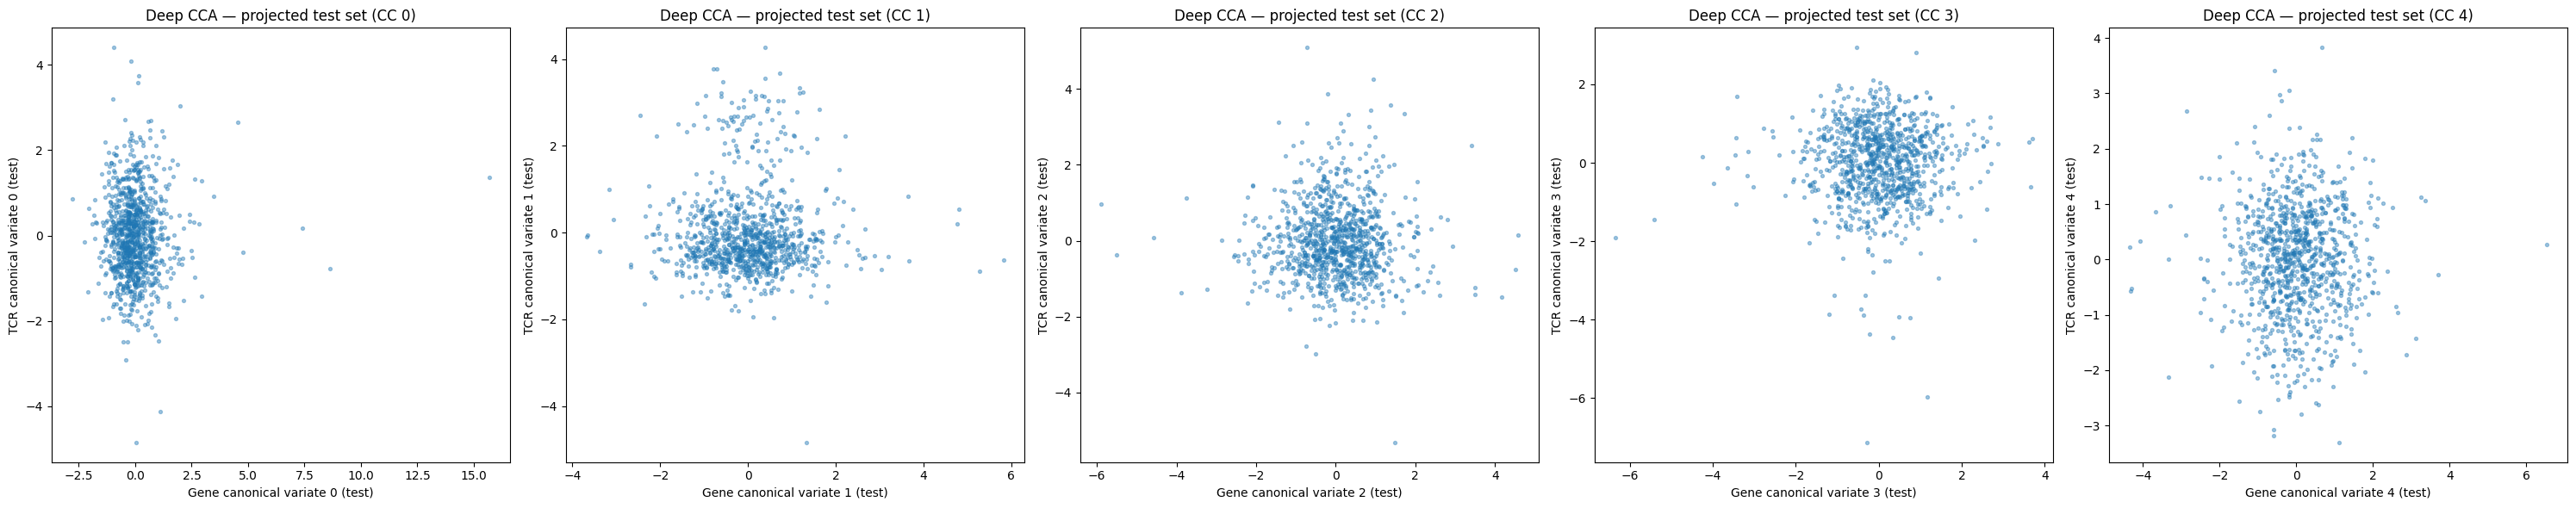

In [15]:
fig, axes = plt.subplots(1, dim_cca, figsize=(6 * dim_cca, 6))
if dim_cca == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.scatter(
        view_gene_c_test[:, i], view_tcr_c_test[:, i],
        alpha=0.4, s=8,
    )
    ax.set_xlabel(f'Gene canonical variate {i} (test)')
    ax.set_ylabel(f'TCR canonical variate {i} (test)')
    ax.set_title(f'Deep CCA — projected test set (CC {i})')

plt.tight_layout()
plt.show()

In [16]:
corr_train, corr_test = TCR_embedings.train_test_corr(view_gene_c_train, view_tcr_c_train, view_gene_c_test, view_tcr_c_test)

Canonical Correlations Comparison:
Component       Train Corr      Test Corr       Difference     
Component 1      0.7698          0.0178          0.7520         
Component 2      0.7504          0.0016          0.7488         
Component 3      0.7463          -0.0131         0.7594         
Component 4      0.7479          0.0174          0.7305         
Component 5      0.7618          0.0073          0.7545         


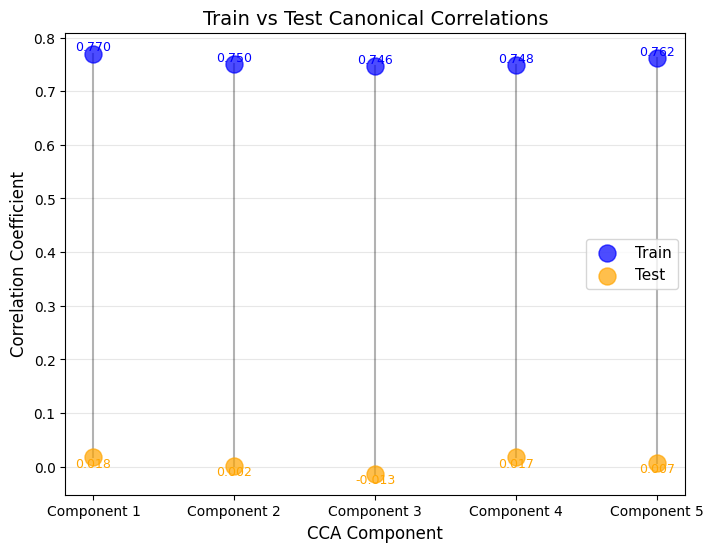

In [17]:
ax = TCR_embedings.plot_train_test_corr(corr_train, corr_test)
# ax.set_ylim(0, 1)

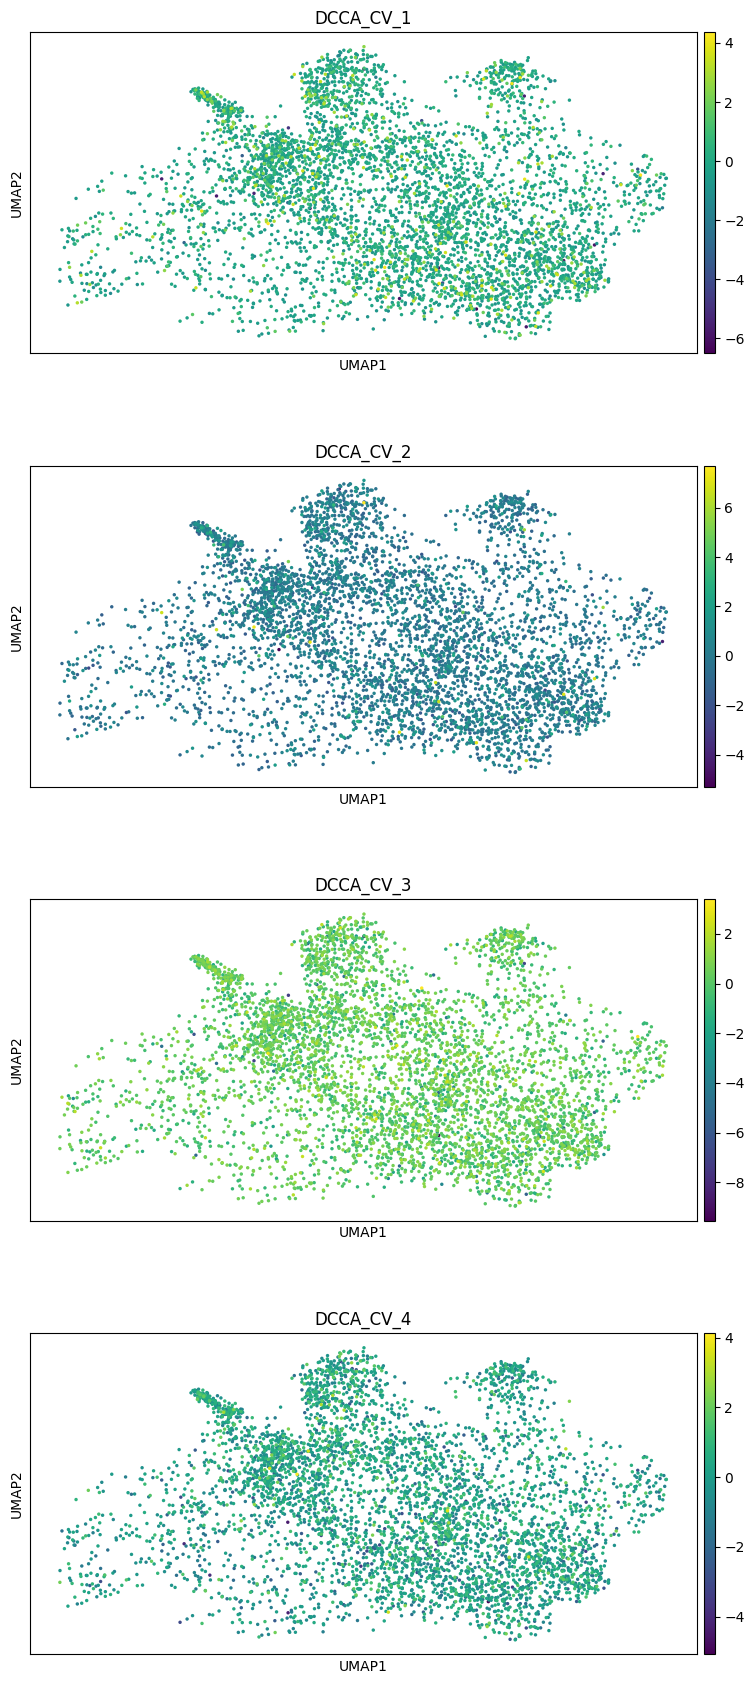

In [18]:
cols = [c for c in (
    'Annotation_minor_subset',
     'DCCA_CV_1',
    'DCCA_CV_2',
    'DCCA_CV_3',
    'DCCA_CV_4',
) if c in mdata['gex'].obs]

sc.pl.umap(mdata['gex'], color=cols, ncols=1, wspace=0.45, hspace=0.35)

## logit regression

In [19]:
aa

NameError: name 'aa' is not defined

In [ ]:
### Logistic Regression per subtype: predict clone_status using DCCA canonical variates ###
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from imblearn.over_sampling import RandomOverSampler
import torch
import torch.nn as nn

tg = target_groups if 'target_groups' in globals() else [
    'Tumor_multiSite_clone',
    'Tumor_singleSite_clone',
]
g1, g2 = tg[0], tg[1]

cs = mdata.obs['clone_status'].astype(str).to_numpy()
sub = mdata.obs['subtype'].astype(str).to_numpy()
in_groups = np.isin(cs, tg)

y_all = (cs == g1).astype(int)

subtypes = sorted(set(sub[in_groups]))

class WeightedLogistic(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.feature_weights = nn.Parameter(torch.ones(n_features))
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x * self.feature_weights).squeeze(-1)

lr_results = []

for st in subtypes:
    st_mask = sub == st
    mask_tr = train_mask & in_groups & st_mask
    mask_te = test_mask & in_groups & st_mask

    X_tr = view_tcr_c[mask_tr]
    X_te = view_tcr_c[mask_te]
    y_tr = y_all[mask_tr]
    y_te = y_all[mask_te]

    if X_tr.shape[0] < 10 or X_te.shape[0] < 4:
        continue
    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
        continue

    ros = RandomOverSampler(random_state=42)
    X_tr_bal, y_tr_bal = ros.fit_resample(X_tr, y_tr)

    # Trainable-weight logistic
    wlr_epochs = 200
    X_tr_t = torch.tensor(X_tr_bal, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_bal, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)

    wlr = WeightedLogistic(X_tr_t.shape[1])
    optimizer = torch.optim.Adam(wlr.parameters(), lr=1e-2)
    loss_fn = nn.BCEWithLogitsLoss()

    wlr.train()
    for epoch in range(wlr_epochs):
        optimizer.zero_grad()
        loss_fn(wlr(X_tr_t), y_tr_t).backward()
        optimizer.step()

    wlr.eval()
    with torch.no_grad():
        y_pred_proba = torch.sigmoid(wlr(X_te_t)).numpy()
        y_pred = (y_pred_proba >= 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    try:
        auc = roc_auc_score(y_te, y_pred_proba)
    except ValueError:
        auc = np.nan

    learned_w = wlr.feature_weights.detach().numpy()

    lr_results.append({
        'subtype': st,
        'n_train': X_tr_bal.shape[0],
        'n_test': X_te.shape[0],
        'accuracy': acc,
        'roc_auc': auc,
        'feature_weights': learned_w.tolist(),
    })

    print(f"\n{'='*60}")
    print(f"Subtype: {st}  (train={X_tr_bal.shape[0]}, test={X_te.shape[0]})")
    print(f"{'='*60}")
    print(f"Feature weights: {learned_w}")
    print(f"Accuracy: {acc:.4f}   ROC AUC: {auc:.4f}")
    print(classification_report(y_te, y_pred, target_names=[g2, g1], zero_division=0))

lr_results_df = pd.DataFrame(lr_results)
lr_results_df
